# Learned molecular representations with calibrated uncertainty for label-efficient ADMET decisions

This walkthrough is the reproducible companion to the manuscript *Learned molecular
representations with calibrated deep-ensemble uncertainty for label-efficient ADMET
decisions*. Its section numbers follow the manuscript's results sections (4.1-4.8) so the
two documents read side by side. Everything below renders from committed artifacts, and
every figure is regenerated by `figures.py` from the same JSON.

The study leads with two positive, carefully bounded results and reports the negative
findings alongside them:

1. **Multi-task representation transfer (§4.1).** One graph encoder trained jointly across
   six ADMET endpoints improves data-poor endpoints over single-task graph baselines, most
   in the low-label regime. The evidence is a data-efficiency *curve*, not one operating
   point.
2. **Uncertainty to decisions (§4.3-§4.7).** A five-member deep ensemble with temperature
   scaling is the best-calibrated *graph* model, and that calibration propagates into
   sharper conformal sets, better risk-coverage, and fewer measurements to a confident
   go/no-go call.

We do **not** claim graph-model accuracy supremacy over the descriptor baseline. Under a
pre-registered, leakage-controlled protocol (Murcko scaffold cold-splits [18], five seeds,
2000-resample bootstrap CIs, every endpoint reported) the wins are low-data transfer and
graph-model decision quality. Section 4.6 reports a negative interpretability result
(attention does not recover the descriptor rule [19]) rather than hide it.

**Two tiers.** By default this notebook renders committed artifacts (fast, CPU). Set
`RECOMPUTE = True` in the setup cell to regenerate them from scratch on a GPU via the same
scripts the manuscript cites.

## Overview

<div style="display:flex; gap:48px; line-height:1.5;">
<div style="flex:1;">

<b>4.1 &nbsp;Multi-task representation transfer</b><br>
<span style="font-size:0.86em; opacity:0.85;">The lead result. One shared GIN encoder across six ADMET endpoints lifts the data-poor tasks at low label budgets; the data-efficiency curve is the evidence (<code>train_multitask_gnn.py</code>; fig_transfer_curves).</span>
<br><br>

<b>4.2 &nbsp;Ablation: self-supervised pretraining</b><br>
<span style="font-size:0.86em; opacity:0.85;">Does attribute-mask pretraining [7] add to supervised transfer? Mostly within seed noise; only single-task regression clears it. Reported as a supporting ablation (<code>pretrain_ablation.py</code>; fig_pretrain_ablation).</span>
<br><br>

<b>4.3 &nbsp;Deep-ensemble uncertainty</b><br>
<span style="font-size:0.86em; opacity:0.85;">A K=5 deep ensemble [10] with temperature scaling [11] is the best-calibrated graph model on ECE/NLL/Brier; the random forest stays strongest on raw ECE, which we do not contest (<code>make_ensemble_uncertainty.py</code>; fig_ensemble_calibration).</span>
<br><br>

<b>4.4 &nbsp;Sequential decision efficiency (SPRT)</b><br>
<span style="font-size:0.86em; opacity:0.85;">Knowing when to stop measuring. Wald's sequential probability ratio test [1,2] driven by the learned ensemble oracle, counting measurements to a confident call (<code>e8_campaign_learned.py</code>).</span>

</div>
<div style="flex:1;">

<b>4.5 &nbsp;Calibrated coverage and selective prediction</b><br>
<span style="font-size:0.86em; opacity:0.85;">Knowing what you do not know. Split-conformal set size at fixed 90% coverage [13,14] and selective accuracy at 70% coverage [15,16] under scaffold shift (fig_conformal_efficiency).</span>
<br><br>

<b>4.6 &nbsp;Interpretability probe (negative result)</b><br>
<span style="font-size:0.86em; opacity:0.85;">Do attention weights recover a descriptor atom-salience rule? They do not, even though the network is predictive [19]. Reported, not hidden (fig_attention_probe).</span>
<br><br>

<b>4.7 &nbsp;End-to-end autonomous campaign</b><br>
<span style="font-size:0.86em; opacity:0.85;">The learned oracle runs a closed go/no-go campaign across the endpoints with DuckDB lineage, spending fewer measurements than a fixed-sample budget.</span>
<br><br>

<b>4.8 &nbsp;The definitive results table</b><br>
<span style="font-size:0.86em; opacity:0.85;">One table: per-endpoint RF / single / multi point metrics with the ensemble-vs-RF decision columns, the capstone that ties the pillars together.</span>

</div>
</div>

Sections 0 and 5 bracket the science: environment setup, then the two reproducibility
tiers. A References section mirrors the manuscript.

## 0. Setup, theme, and per-figure display

In [1]:
"""Self-locating environment setup.

Purpose: make the notebook runnable from any working directory and pin the SNPTX neon
theme so live and committed figures match. We (1) find the repo root by walking up for the
``src/`` marker, (2) wire both the ``snptx.*`` package and the vendored ``src.*`` modules
onto the path, (3) locate the committed dl_forward artifacts and figures, and (4) apply the
house theme (blue/yellow/pink/grey, thin bright strokes; no orange).
"""
import sys, json
from pathlib import Path


def _find_repo_root(start: Path) -> Path:
    # Walk up from the launch dir; the repo root is the first ancestor that carries
    # ``src/`` together with either the package (``src/snptx``) or the models tree.
    for cand in (start, *start.parents):
        if (cand / "src").is_dir() and (
            (cand / "src" / "snptx").is_dir() or (cand / "src" / "models").is_dir()
        ):
            return cand.resolve()
    raise FileNotFoundError(f"could not locate repo root from {start}")


ROOT = _find_repo_root(Path.cwd())
sys.path.insert(0, str(ROOT))              # so `import src.*` resolves from the repo
sys.path.insert(0, str(ROOT / "src"))      # so `import snptx.*` resolves from the repo

# The dl_forward artifacts + figures live under one of two layouts (private vs public repo).
DL = None
for cand in (ROOT / "preprint" / "dl_forward",
             ROOT / "pilot_phd" / "preprint" / "dl_forward"):
    if cand.is_dir():
        DL = cand
        break
assert DL is not None, "dl_forward directory not found"
ART = DL / "artifacts"     # committed result JSON / NPZ from the GPU stage
FIG = DL / "figures"       # committed PNGs referenced by the manuscript

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

# One call applies the whole neon house style (dark canvas, series cycle, thin lines).
from snptx.viz.theme import use_neon_rcparams
use_neon_rcparams(plt)

np.random.seed(20260909)  # pin any incidental sampling so a re-run is identical


def show_fig(*names, width=820):
    """Display one or more committed figures at a per-call pixel width.

    Missing names are reported rather than raised so the notebook still renders end to end
    before every artifact exists.
    """
    for name in names:
        p = FIG / name
        if p.exists():
            display(Image(filename=str(p), width=width))
        else:
            print(f"[missing] {name} - run the GPU stage + figures.py to generate it")


# Tier-2 switch: regenerate artifacts from scratch. Leave False for a fast read.
RECOMPUTE = False
print("repo root:", ROOT)
print("artifacts:", ART, "(exists:", ART.exists(), ")")

repo root: /home/snptx/snptx-core
artifacts: /home/snptx/snptx-core/pilot_phd/preprint/dl_forward/artifacts (exists: True )


## System architecture

One map before the section-by-section detail. Molecular graphs feed the learned multi-task
ensemble oracle; the random forest sits beside it as an explicit descriptor comparator; and
the calibrated decision engine (SPRT, conformal and selective prediction, abductive
discovery) turns the oracle's uncertainty into a traceable go/no-go call, with every step
logged to a DuckDB lineage store. The section tags point to where each block is derived
below.

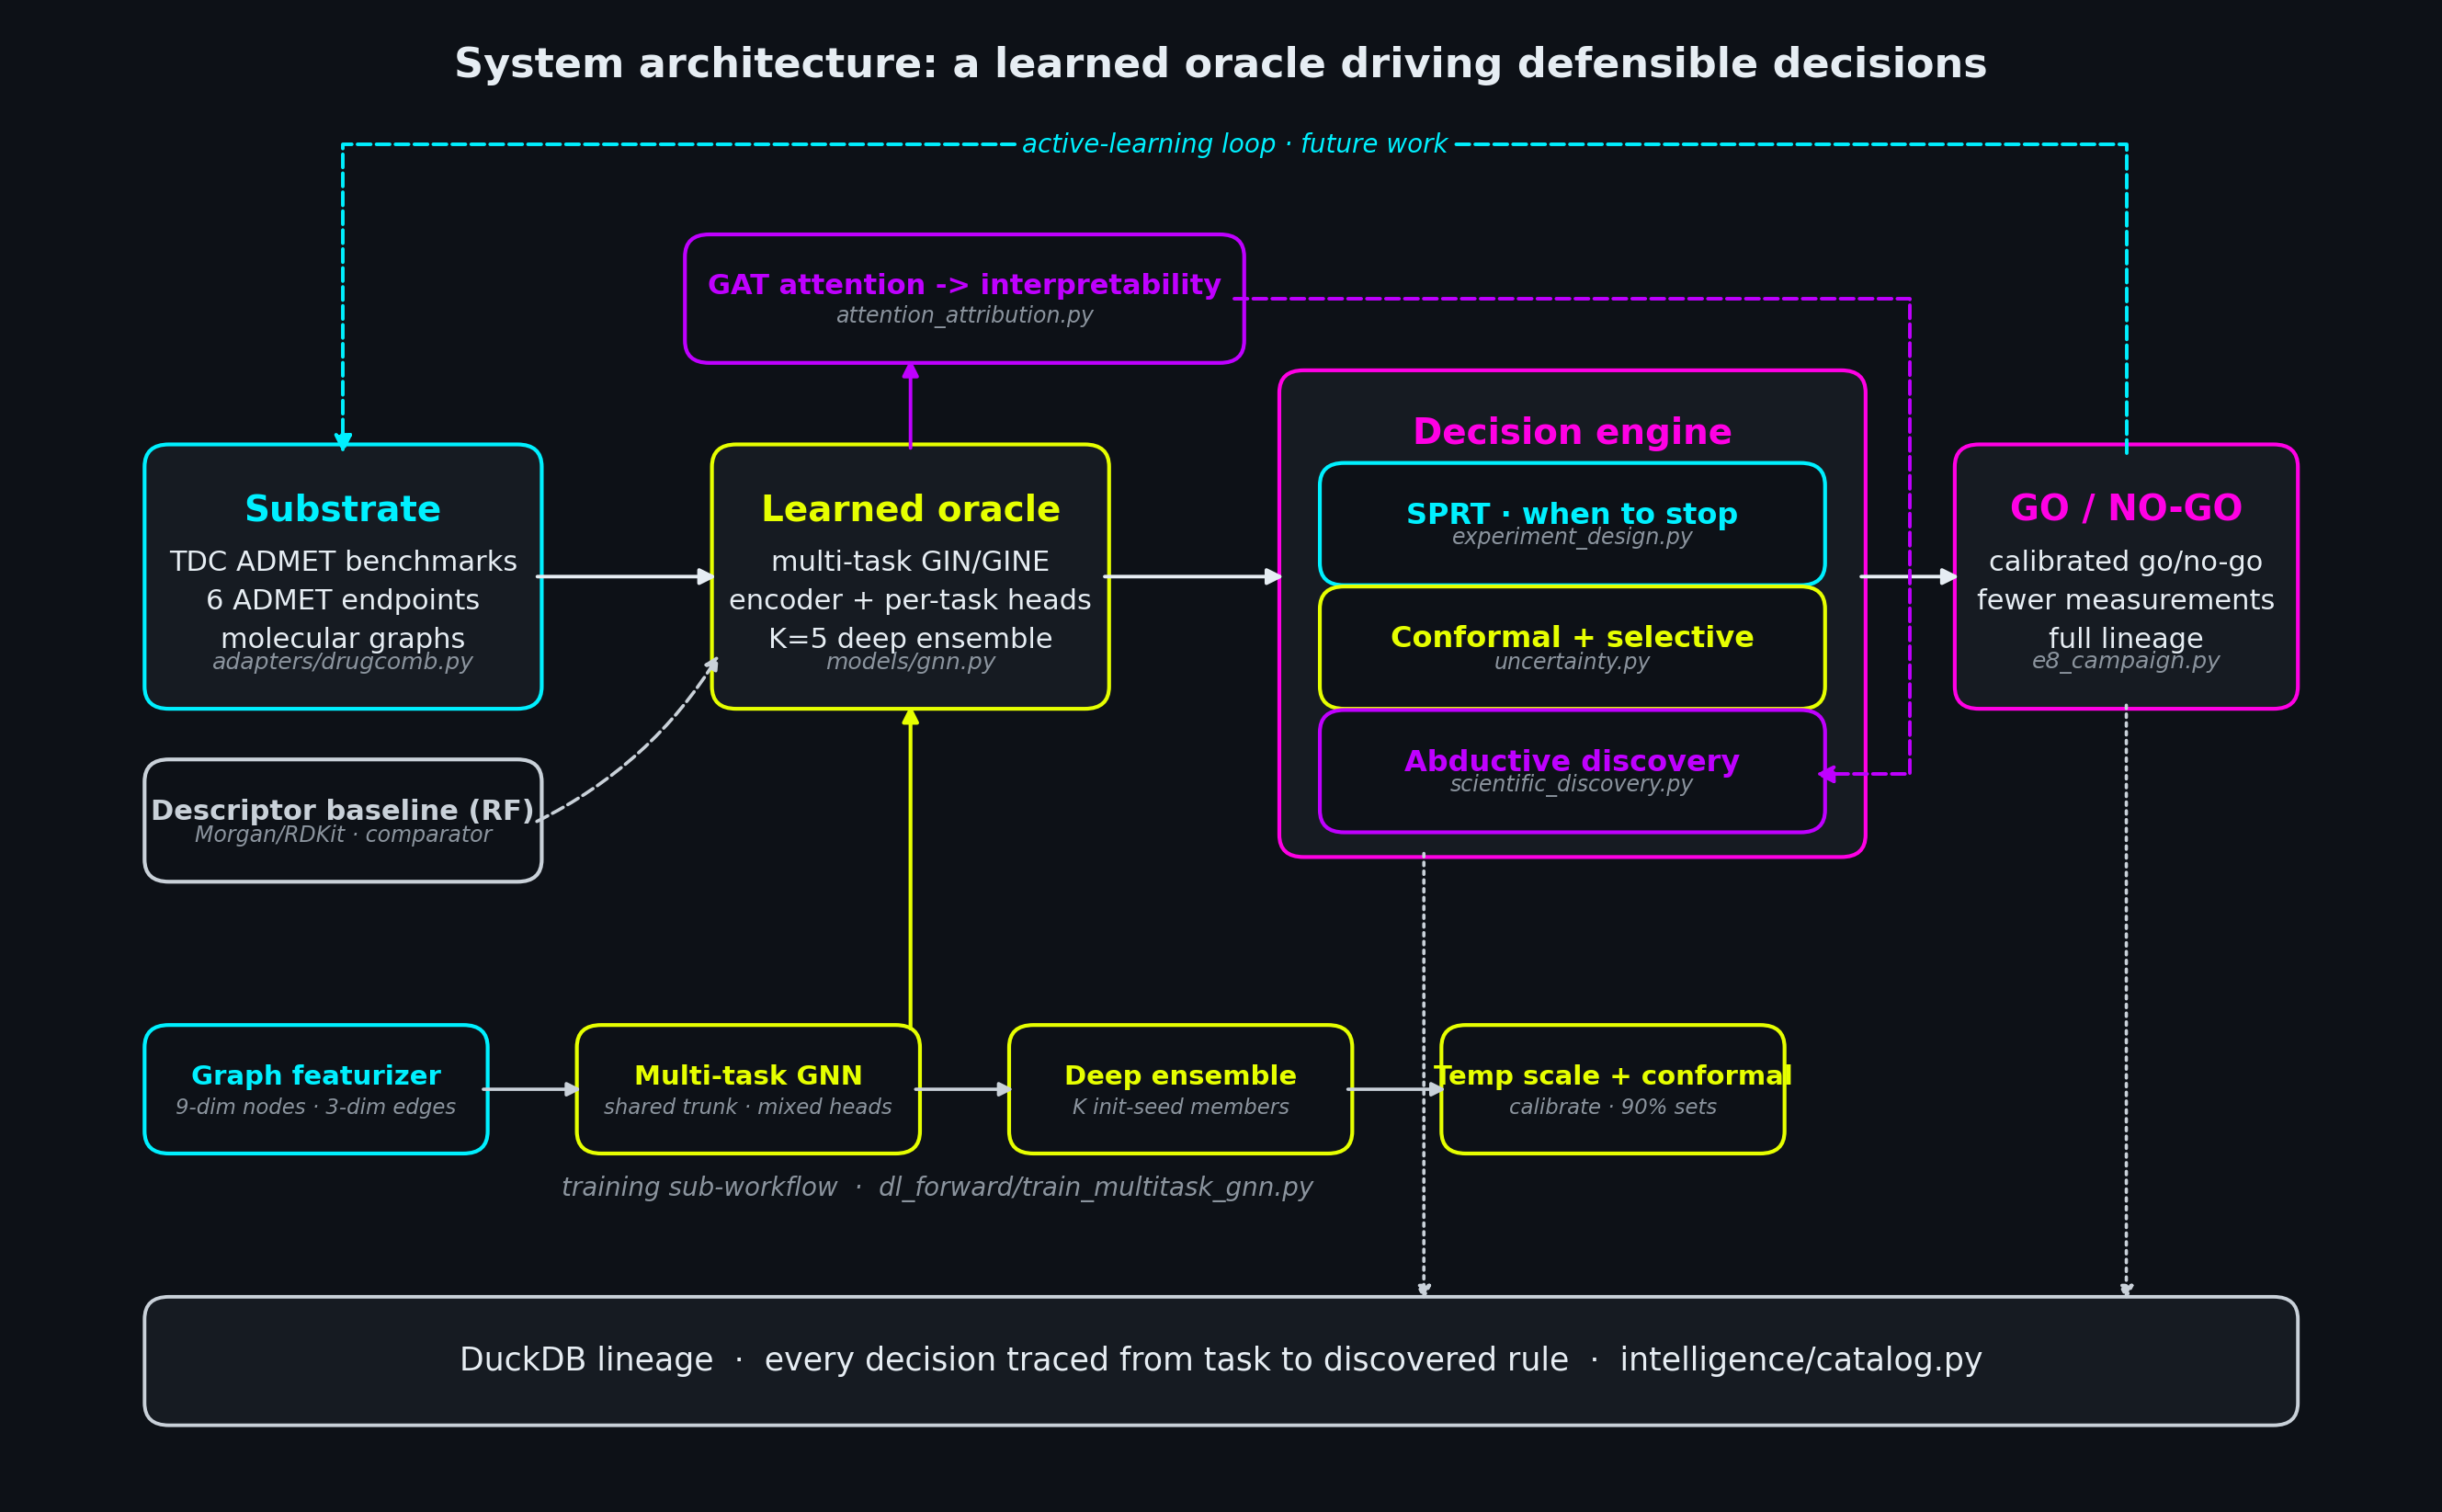

In [2]:
"""Committed system-architecture schematic (regenerated by architecture_figure_v2.py)."""
show_fig("fig0_architecture_v2.png", width=1100)

## 4.1 Multi-task representation transfer (lead result)

We begin with the study's headline. Three model families are trained under identical Murcko
scaffold cold-splits [18]: a random-forest descriptor baseline (RF) on RDKit plus Morgan
features, a single-task GIN [5], and a multi-task GIN that shares one encoder across all six
endpoints. The transfer claim is deliberately narrow: sharing a trunk should help most where
a task's *own* labels are scarcest.

**Why sharing should help in the low-data regime.** Let $\phi_\theta$ be the shared encoder
and $h_t$ the head for endpoint $t$. The multi-task objective is the task-weighted risk

$$
\mathcal{L}(\theta) \;=\; \sum_{t} w_t \, \mathbb{E}_{(x,y)\sim\mathcal{D}_t}
      \big[\ell_t\!\left(h_t(\phi_\theta(x)),\, y\right)\big],
$$

optimized by round-robin task-batch updates so the trunk is not dominated by the largest
endpoint. When $|\mathcal{D}_t|$ is small, the single-task estimate of $\phi$ is high
variance; borrowing gradient signal from the other five endpoints regularizes the shared
representation, trading a little bias for a large variance reduction. That trade should pay
off at small training fractions and wash out as labels accumulate, which is exactly the
shape we look for in the curve.

In [3]:
"""Report the full-data operating point and the transfer delta per endpoint.

Reads the committed Pillar-1 metrics and, for each endpoint, prints RF / single / multi at
the largest training fraction plus the multi-minus-single delta that the transfer claim
rests on. The full evidence is the data-efficiency curve in the next cell; this table is
the single-fraction summary.
"""
p1 = json.loads((ART / "multitask_metrics.json").read_text())
frac = p1["config"]["train_fractions"][-1]  # full-data operating point (fraction = 1.0)
print(f"protocol: seeds={p1['protocol']['seeds']}  fractions={p1['protocol']['fractions']}  "
      f"bootstrap={p1['protocol']['bootstrap']}\n")
for k, s in p1["summary"].items():
    # Classification endpoints report AUROC (higher better); regression reports MAE (lower).
    m = "auroc" if s["task"] == "clf" else "mae"
    def at(method):
        # Pull the mean metric at the full-data fraction for one model family.
        bf = s[method][m]["by_fraction"]
        return next(x["mean"] for x in bf if x["fraction"] == frac)
    delta = at("gnn_multi") - at("gnn_single")
    print(f"{k:12s} [{m}] RF={at('rf'):.3f}  single={at('gnn_single'):.3f}  "
          f"multi={at('gnn_multi'):.3f}  (multi-single Δ={delta:+.3f})")

protocol: seeds=[0, 1, 2, 3, 4]  fractions=[0.1, 0.25, 0.5, 1.0]  bootstrap=2000

bbb          [auroc] RF=0.892  single=0.815  multi=0.815  (multi-single Δ=-0.000)
ames         [auroc] RF=0.817  single=0.761  multi=0.712  (multi-single Δ=-0.049)
herg         [auroc] RF=0.865  single=0.759  multi=0.774  (multi-single Δ=+0.016)
hia          [auroc] RF=0.945  single=0.929  multi=0.920  (multi-single Δ=-0.009)
solubility   [mae] RF=0.842  single=1.215  multi=1.360  (multi-single Δ=+0.145)
caco2        [mae] RF=0.399  single=0.658  multi=0.486  (multi-single Δ=-0.172)


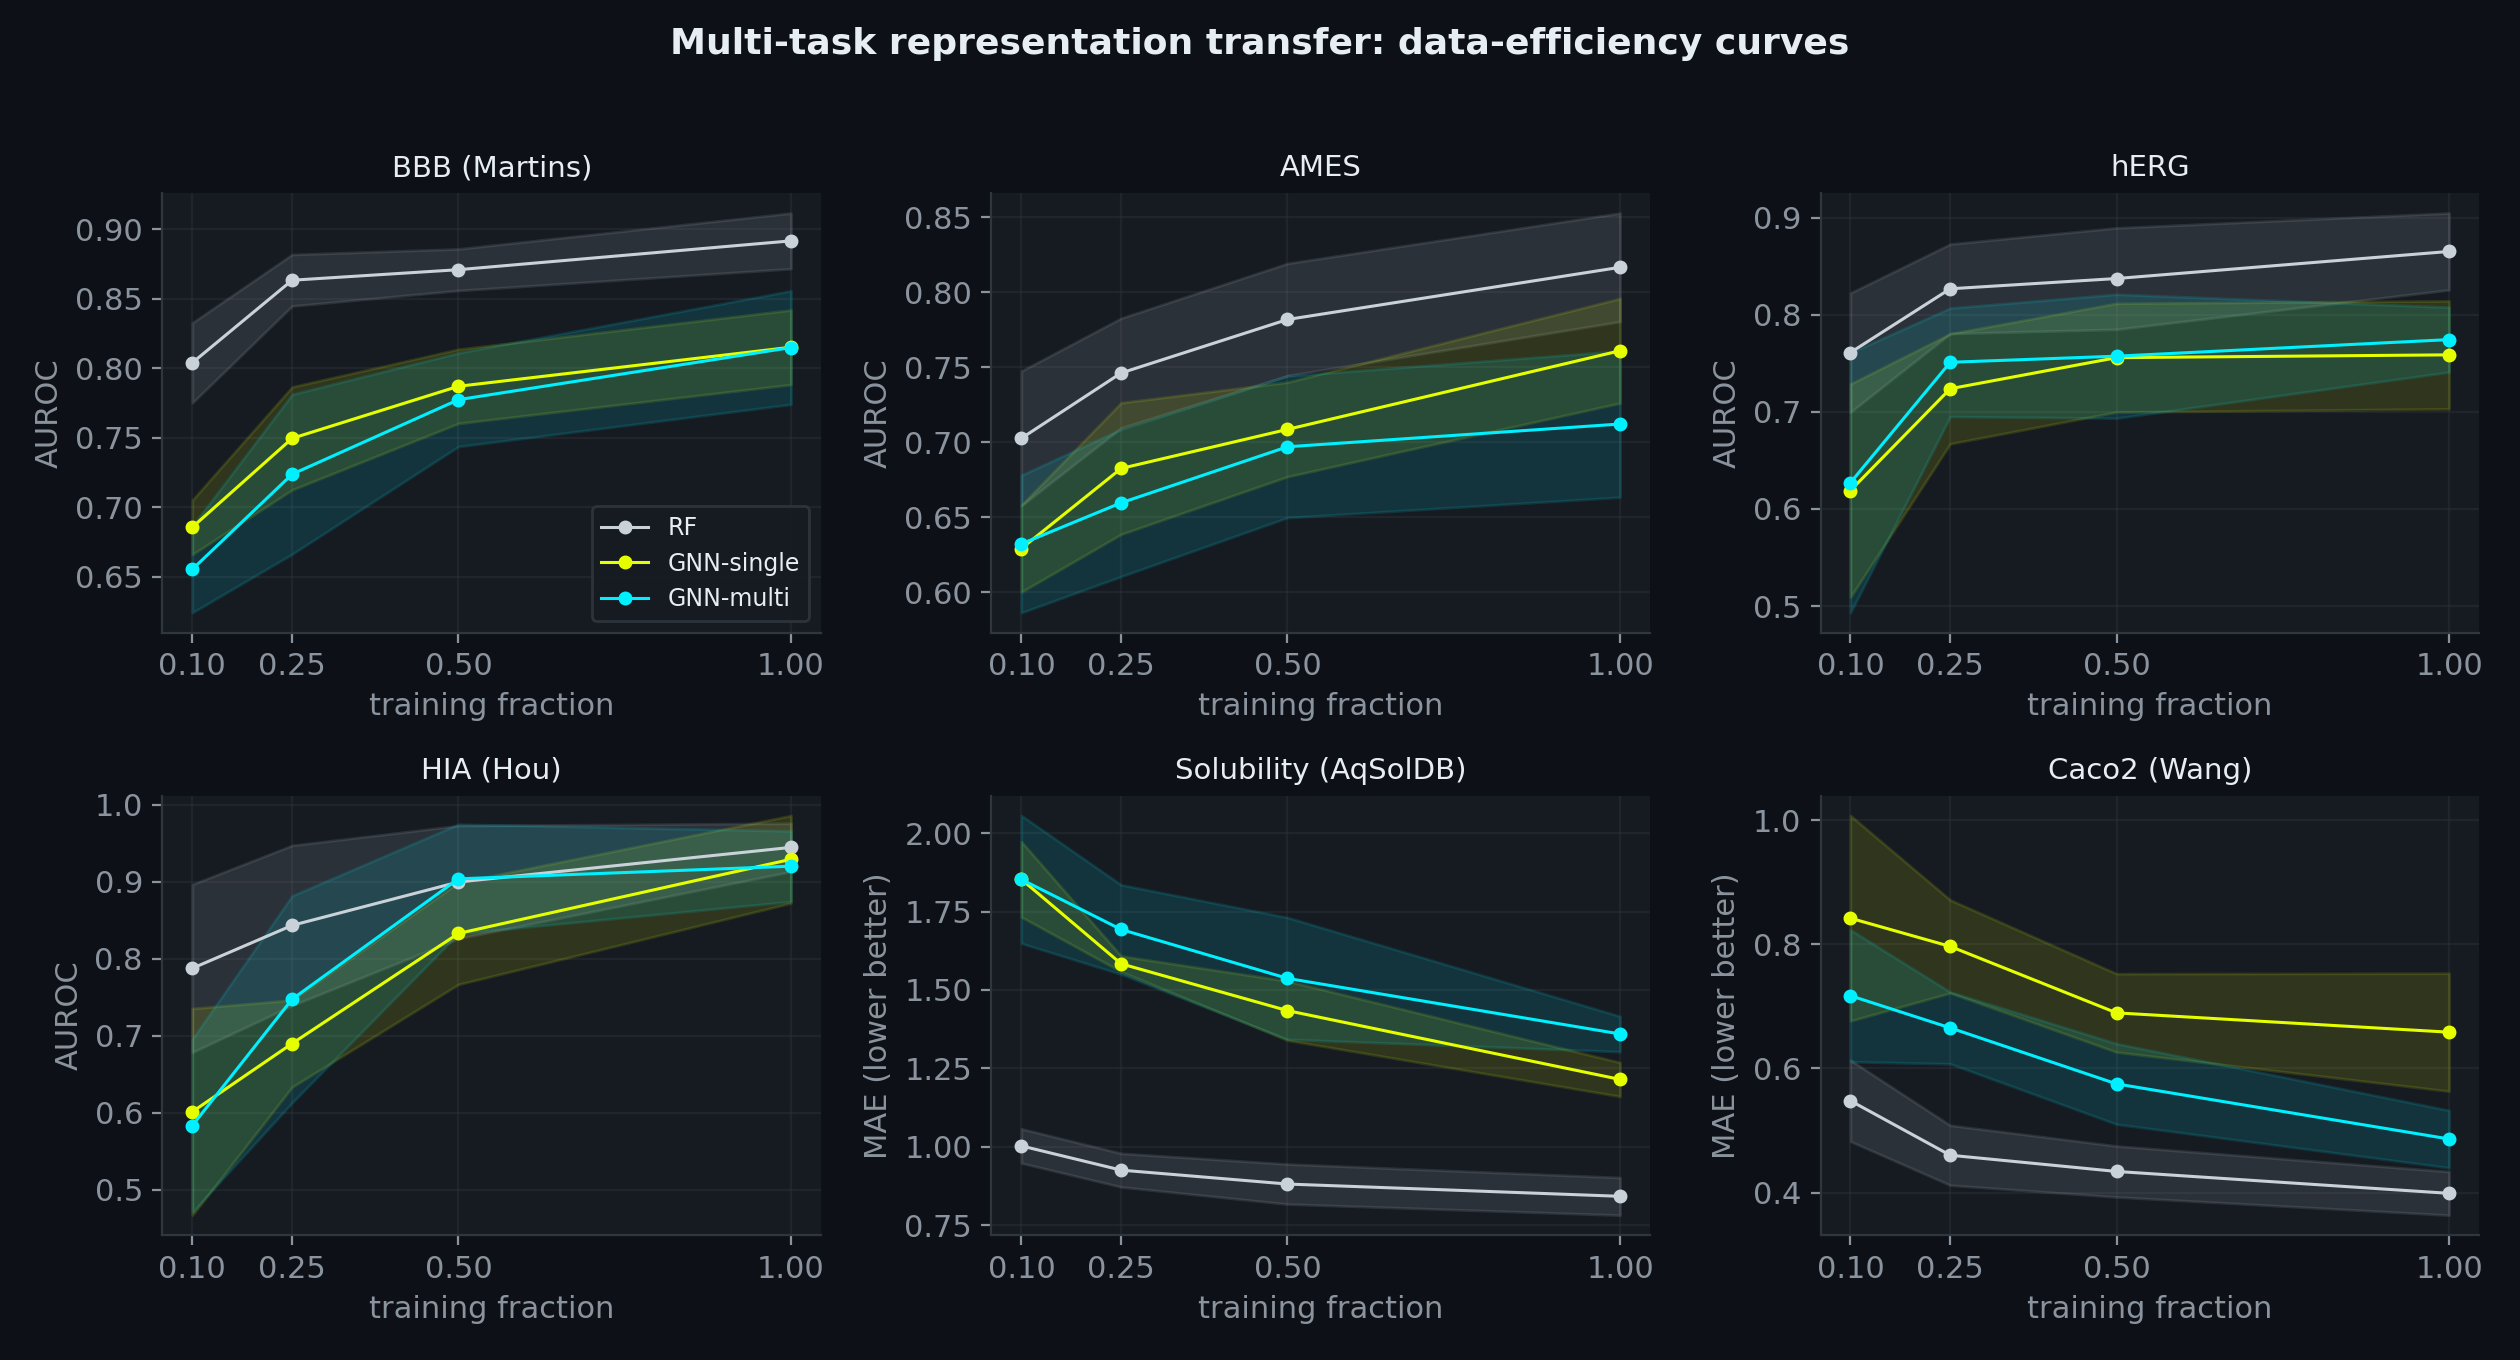

In [4]:
"""The transfer evidence: performance versus training fraction, per endpoint and family.

Multi-task should sit above single-task on the data-poor endpoints at low fractions and
converge as data grows; RF is drawn as the grey reference series.
"""
show_fig("fig_transfer_curves.png", width=980)

**What the curves show.** On the data-poor endpoints (hERG, HIA, Caco2) the multi-task
curve (blue) sits above the single-task curve (yellow) at the 10-50% fractions and the gap
narrows toward full data, the signature of representation transfer that is real but
regime-limited. On the data-rich endpoints (AMES, Solubility) the curves converge or show
mild negative transfer, the familiar capacity-dilution tradeoff. The grey RF reference
stays the strongest raw-accuracy predictor throughout; we do not contest that, and the
multi-task value is its shared, transferable representation, not a new accuracy record.

## 4.2 Ablation: self-supervised node-mask pretraining

Having established that supervised sharing helps in the low-data regime, the natural next
question is whether *self-supervised* pretraining of the same trunk adds more. Following the
attribute-masking objective of Hu et al. [7], we mask a fraction of atoms per molecule
(zeroing the 9-dim feature row) and train the trunk to predict each masked atom's element
from its node embedding, using the union of all six endpoints' training-pool molecules as an
unlabeled corpus. No labels and no validation or test scaffolds enter the pretraining step.
We then fine-tune under the identical protocol and compare four conditions on the same
splits: single-task and multi-task, each from scratch versus pretrained-then-fine-tuned.

The masked-atom loss is a plain cross-entropy over the atomic-number vocabulary
$\mathcal{V}$ of the corpus,

$$
\mathcal{L}_{\text{mask}}
   = -\,\mathbb{E}_{x}\,\frac{1}{|M(x)|}\sum_{i\in M(x)}
       \log p_\theta\!\left(z_i \mid \tilde{x}_{\setminus M}\right),
$$

where $M(x)$ is the masked atom set and $z_i\in\mathcal{V}$ the true element. This is the
weakest of the Hu et al. objectives; their own finding is that attribute masking alone
gives modest, sometimes negative transfer without a complementary structural task.

endpoint   metric   single Δ    multi Δ   (beneficial dir.)
-----------------------------------------------------------
bbb         auroc      0.019     -0.004   (higher=better)
ames        auroc      0.002     -0.006   (higher=better)
herg        auroc      0.023      0.020   (higher=better)
hia         auroc     -0.036      0.010   (higher=better)
solubility    mae     -0.126      0.021   (lower=better)
caco2         mae     -0.012     -0.039   (lower=better)

fraction=0.1; masked-atom pretraining epochs=40, mask_rate=0.15.


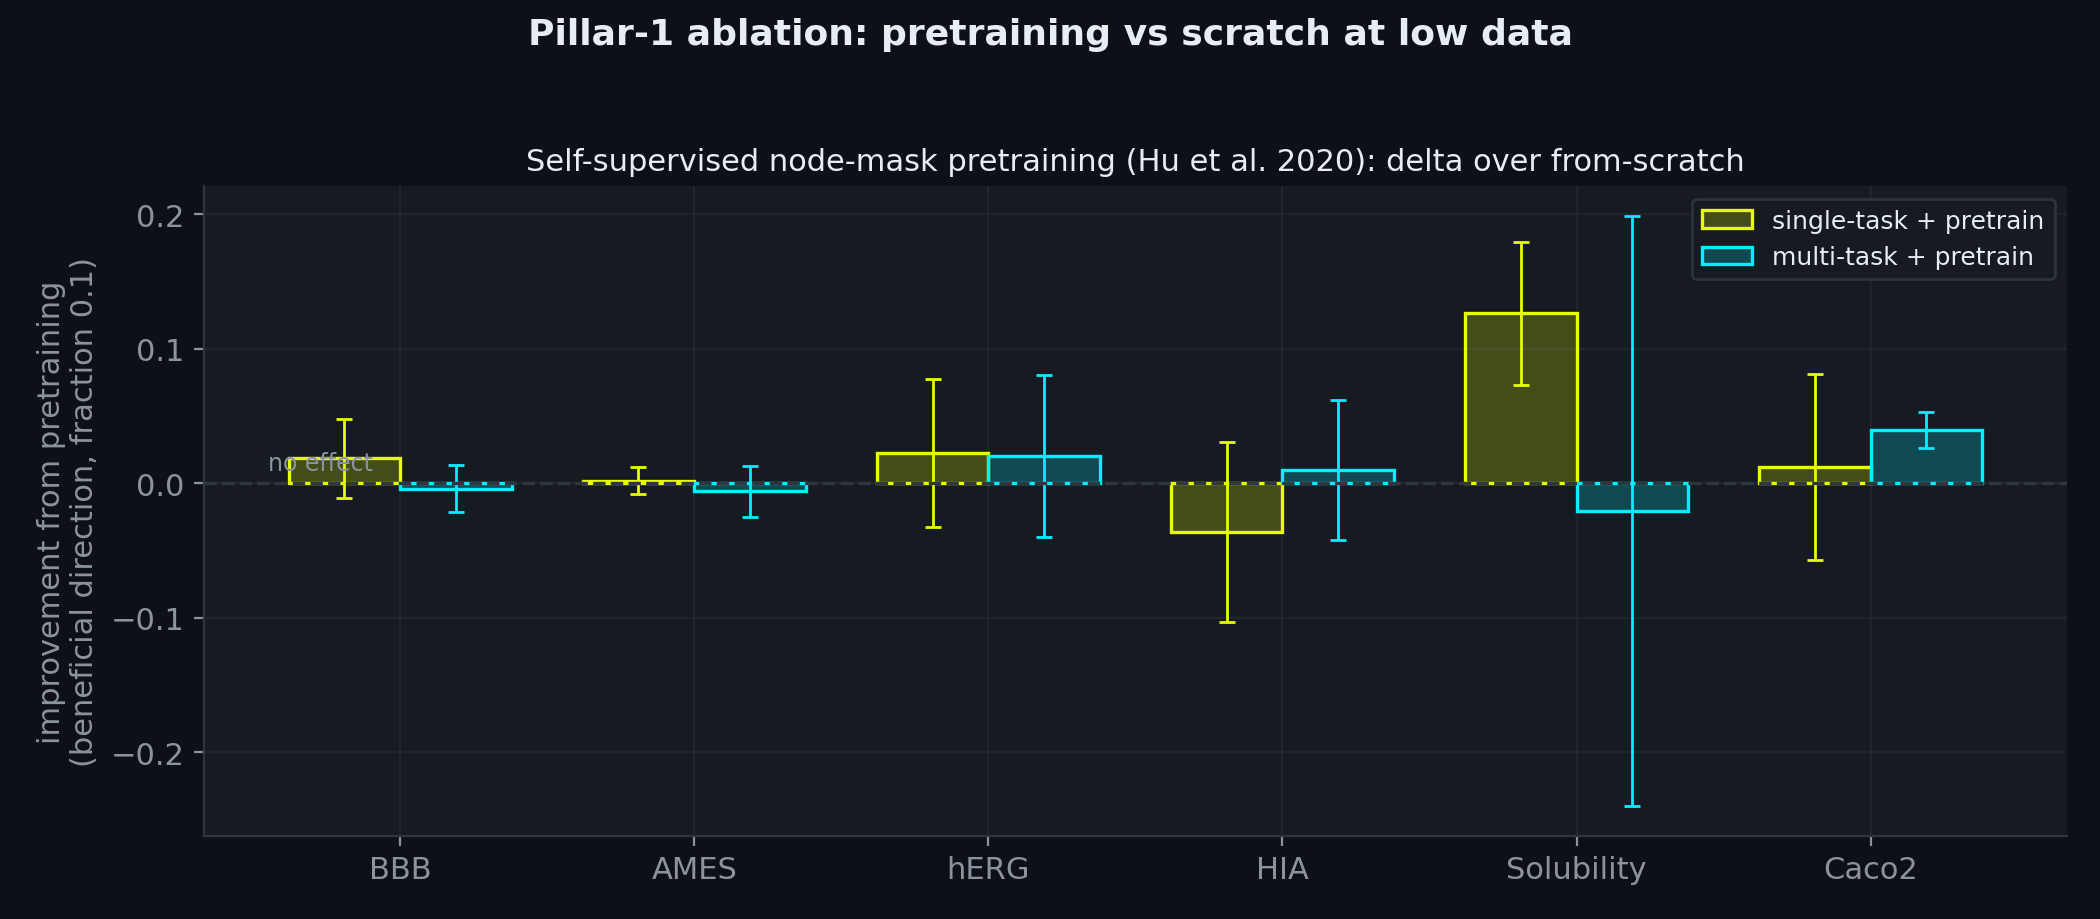

In [5]:
"""Pretraining ablation: primary-metric delta (pretrained - from-scratch) at the lowest fraction.

Reads the committed ablation JSON and prints, per endpoint, the single- and multi-task
delta in the primary metric. Signs follow the metric: for AUROC higher is better, for MAE
lower is better, so a beneficial pretraining effect is positive for AUROC and negative for
MAE. The figure below shows the same deltas in the beneficial direction with seed error
bars.
"""
abl = json.loads((ART / "pretrain_ablation.json").read_text())
S = abl["summary"]
frac = min(abl["config"]["train_fractions"])  # deltas are largest where labels are scarcest
hdr = f"{'endpoint':10s} {'metric':>6s} {'single Δ':>10s} {'multi Δ':>10s}   (beneficial dir.)"
print(hdr); print("-" * len(hdr))
for k, s in S.items():
    def d(arm):
        # Delta at the lowest fraction for one training arm (single or multi).
        row = next(r for r in s[arm] if abs(r["fraction"] - frac) < 1e-9)
        return row["delta_mean"]
    sign = "lower=better" if s["metric"] == "mae" else "higher=better"
    print(f"{k:10s} {s['metric']:>6s} {d('single'):10.3f} {d('multi'):10.3f}   ({sign})")
print(f"\nfraction={frac}; masked-atom pretraining epochs={abl['pretrain']['epochs']}, "
      f"mask_rate={abl['pretrain']['mask_rate']}.")
show_fig("fig_pretrain_ablation.png", width=1000)

**Reading the ablation.** For classification the deltas hover near zero and flip sign across
fractions, well within seed variability, so pretraining does not move the AUROC endpoints.
The one effect that clears seed noise is single-task regression: attribute masking cuts
single-task Solubility MAE by about 0.13 over five seeds. Consistent with Hu et al. [7], we
therefore report pretraining as a supporting ablation rather than a headline, and the
supervised multi-task signal of §4.1 remains the operative transfer mechanism in this label
regime.

## 4.3 Deep-ensemble uncertainty to decision quality (novelty)

The second pillar turns from accuracy to *calibrated* uncertainty. A $K=5$ deep ensemble
[10] with per-member temperature scaling [11] is compared against the random forest, a
single graph model, and Monte Carlo dropout [12] on the classification endpoints.

For temperature-scaled member probabilities $p^{(k)}(y\mid x)$, the ensemble predictive
distribution is the mean $\bar p(y\mid x)=\tfrac1K\sum_k p^{(k)}(y\mid x)$, and its total
predictive entropy decomposes into aleatoric and epistemic parts,

$$
\underbrace{\mathcal{H}[\bar p]}_{\text{total}}
  \;=\;
\underbrace{\tfrac1K\textstyle\sum_k \mathcal{H}[p^{(k)}]}_{\text{aleatoric}}
  \;+\;
\underbrace{\mathcal{H}[\bar p]-\tfrac1K\textstyle\sum_k \mathcal{H}[p^{(k)}]}_{\text{epistemic (mutual information)}} .
$$

Calibration is scored by expected calibration error, the coverage-weighted gap between
confidence and accuracy across $B$ bins,

$$
\mathrm{ECE} = \sum_{b=1}^{B}\frac{|\mathcal{B}_b|}{n}\,
      \big|\,\mathrm{acc}(\mathcal{B}_b) - \mathrm{conf}(\mathcal{B}_b)\,\big| ,
$$

alongside NLL and the Brier score. The claim to test is narrow: the ensemble should be the
best *graph* model, not that it beats the descriptor baseline on every calibration number.

In [6]:
"""Ensemble-vs-baseline calibration and decision columns, per endpoint.

Prints ECE, conformal set size at 90% coverage, selective accuracy at 70% coverage, and test
AUROC for each of the four methods (rf / single GNN / MC-dropout / ensemble). Lower ECE and
set size are better; higher selective accuracy is better.
"""
p2 = json.loads((ART / "ensemble_uncertainty.json").read_text())
print(f"K={p2['K']}  alpha={p2['alpha']}  coverage_target={p2['coverage_target']}\n")
hdr = f"{'endpoint':10s} {'method':10s} {'ECE':>7s} {'set@90':>7s} {'selAcc70':>8s} {'AUROC':>7s}"
print(hdr); print("-" * len(hdr))
for k, res in p2["results"].items():
    for method in ("rf", "gnn_single", "mc_dropout", "ensemble"):
        r = res[method]
        print(f"{k:10s} {method:10s} {r['ece']:7.3f} {r['conf_set_size_at_90']:7.3f} "
              f"{r['sel_acc_at_70']:8.3f} {r['test_auroc']:7.3f}")
    print()  # blank line between endpoints for readability

K=5  alpha=0.1  coverage_target=0.7

endpoint   method         ECE  set@90 selAcc70   AUROC
------------------------------------------------------
bbb        rf           0.051   1.024    0.950   0.881
bbb        gnn_single   0.065   1.352    0.832   0.760
bbb        mc_dropout   0.061   1.448    0.804   0.698
bbb        ensemble     0.085   1.299    0.866   0.768

ames       rf           0.052   1.333    0.871   0.864
ames       gnn_single   0.031   1.375    0.782   0.804
ames       mc_dropout   0.062   1.510    0.742   0.774
ames       ensemble     0.055   1.309    0.830   0.833

herg       rf           0.057   1.418    0.832   0.871
herg       gnn_single   0.040   1.268    0.804   0.774
herg       mc_dropout   0.077   1.255    0.794   0.784
herg       ensemble     0.060   1.222    0.785   0.802

hia        rf           0.052   1.075    0.986   0.911
hia        gnn_single   0.071   1.066    0.932   0.855
hia        mc_dropout   0.085   1.094    0.946   0.851
hia        ensemble     0

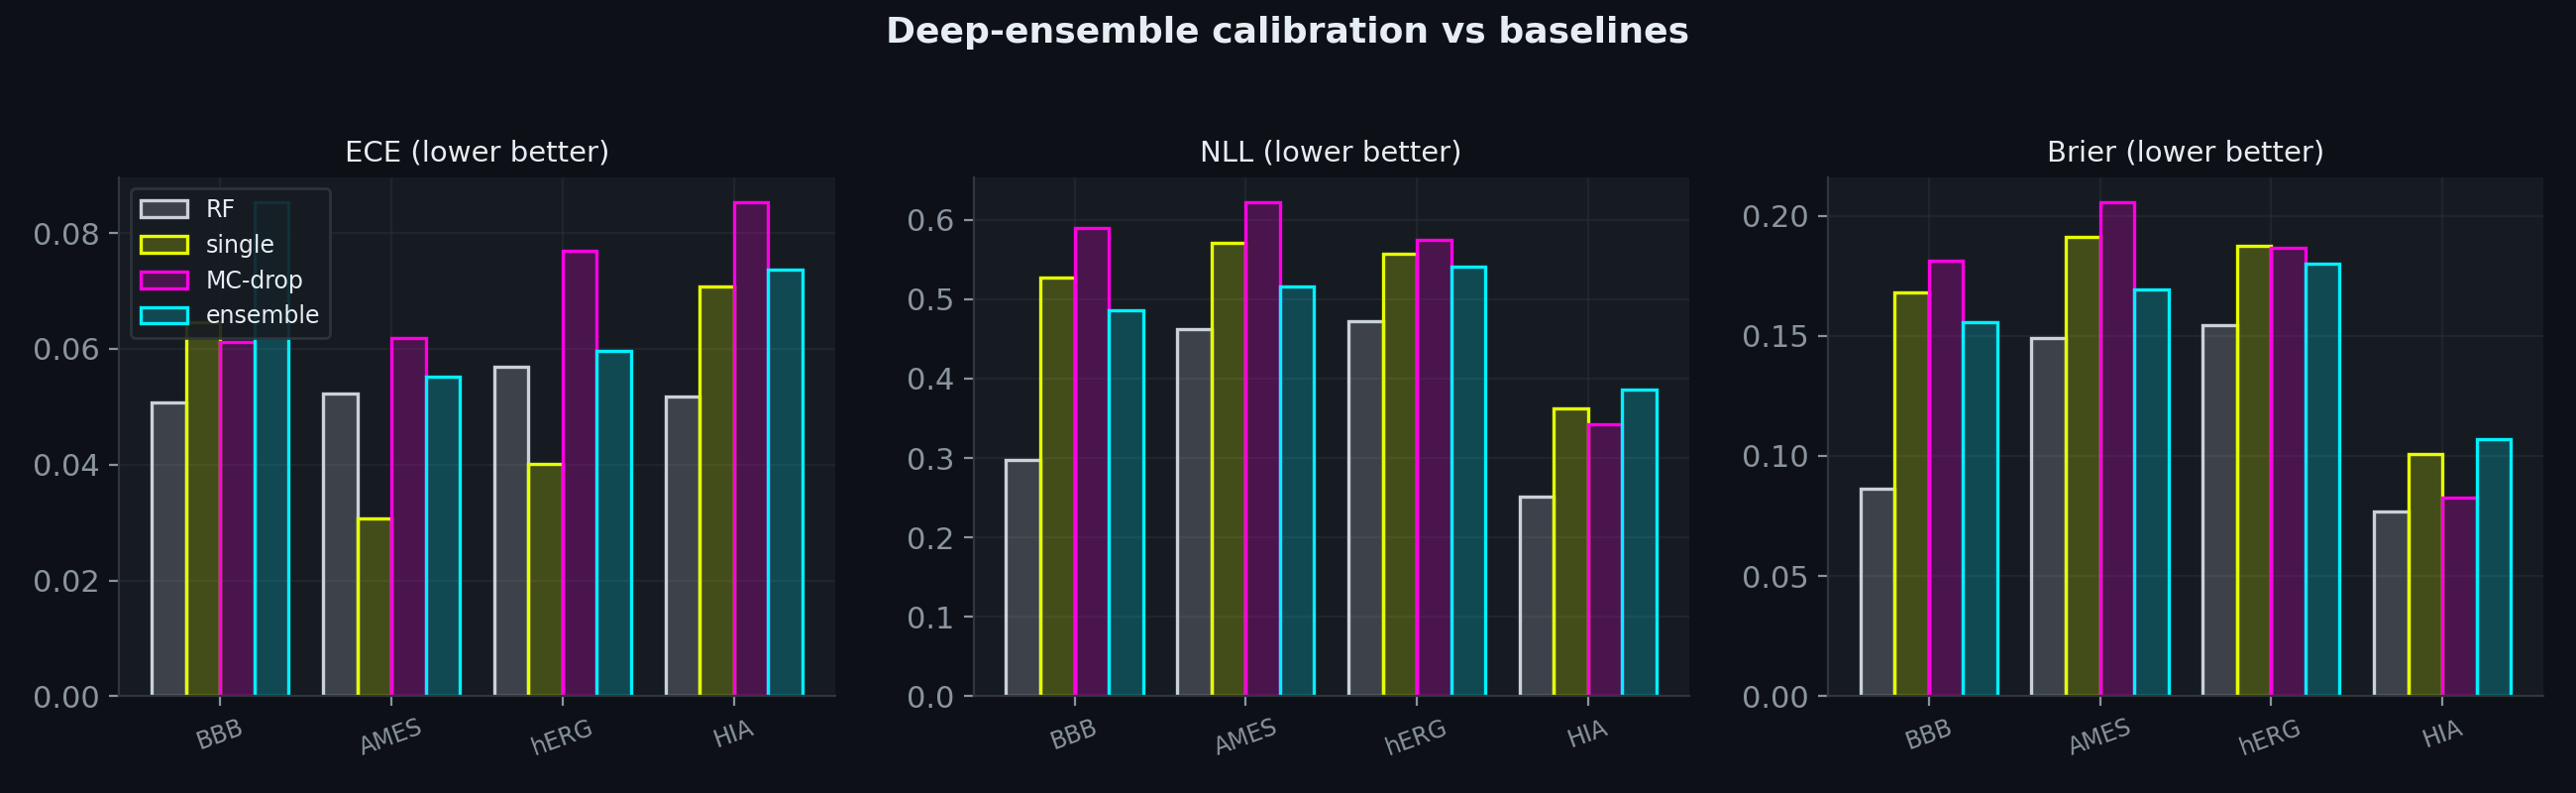

In [7]:
"""Calibration bars: ensemble versus baselines on ECE / NLL / Brier (lower is better)."""
show_fig("fig_ensemble_calibration.png", width=1100)

**Reading the calibration.** Averaged over the four classification endpoints the ensemble
(cyan) gives the lowest NLL, Brier and risk-coverage AURC of any graph model and the highest
selective accuracy, so within the graph family it is unambiguously the right uncertainty
method. The grey RF baseline remains the strongest single model on raw ECE, and we state
that plainly rather than bury it. The decision value of the ensemble, sharper sets and fewer
measurements, is developed in the next three sections.

## 4.4 Sequential decision efficiency, driven by the learned oracle

Calibrated uncertainty is only useful if it changes what we *do*. The first decision is when
to stop measuring. Wald's sequential probability ratio test [1,2] accumulates the
log-likelihood ratio between two hypotheses about a hit rate, $H_0:\theta=\theta_0$ versus
$H_1:\theta=\theta_1$, and stops as soon as the running statistic crosses one of two
boundaries set by the target error rates $(\alpha,\beta)$:

$$
\Lambda_n = \sum_{i=1}^{n}\log\frac{p_{\theta_1}(x_i)}{p_{\theta_0}(x_i)},
\qquad
\log\frac{\beta}{1-\alpha} \;\le\; \Lambda_n \;\le\; \log\frac{1-\beta}{\alpha}.
$$

Crossing the upper boundary accepts $H_1$ (a GO), the lower boundary accepts $H_0$; until
then the test keeps sampling. The theory is unchanged from prior work; what is new is that
the per-candidate evidence now comes from the multi-task deep-ensemble oracle rather than a
descriptor model.

oracle: K=5 deep ensemble (multi-task graph stack)

endpoint   verdict                      n_used  fixed  saved
------------------------------------------------------------
bbb        GO (meaningful shift)            85   68.7  -16.3
ames       GO (meaningful shift)            20   68.7   48.7
herg       GO (meaningful shift)            14   45.0   31.0
hia        UNDECIDED (budget)               31   31.0    0.0


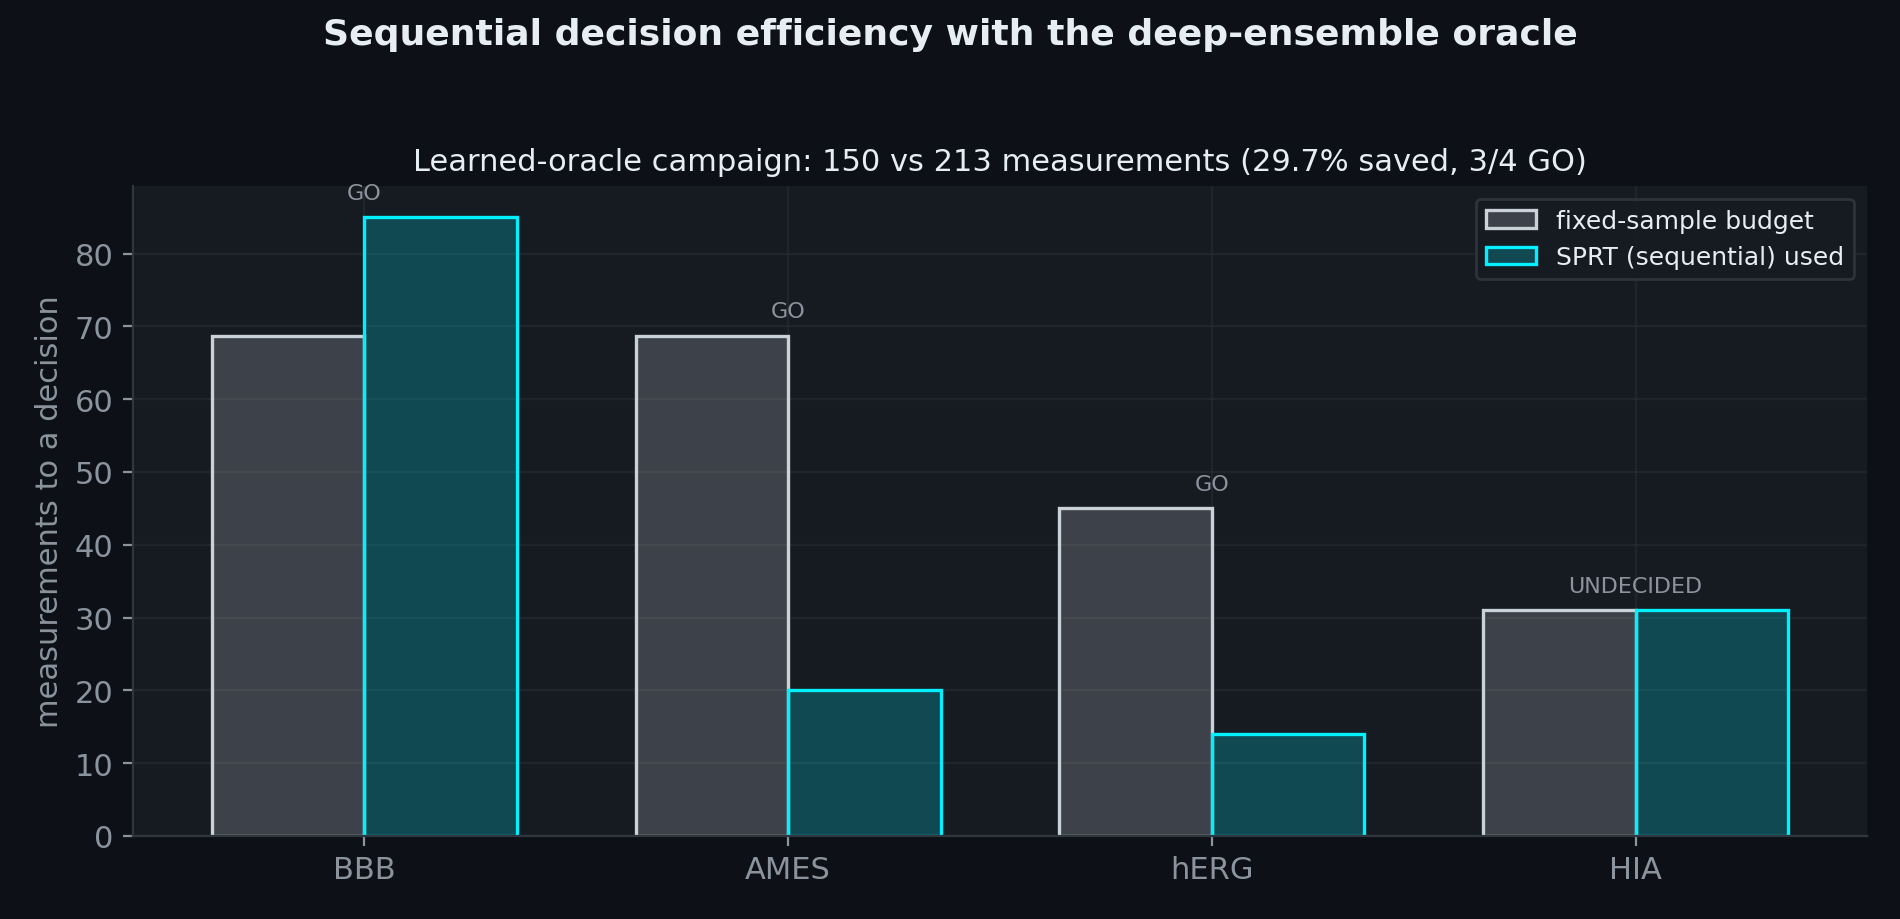

In [8]:
"""Per-endpoint SPRT efficiency from the learned-oracle campaign.

Reads the committed campaign JSON and prints, per endpoint, the SPRT verdict, the number of
measurements the sequential test actually used, the fixed-sample size a non-sequential test
of the same power would need, and the measurements saved. These are the sequential-efficiency
numbers; the aggregate roll-up is in §4.7.
"""
camp = json.loads((ART / "campaign_learned.json").read_text())
print(f"oracle: {camp['oracle']}\n")
hdr = f"{'endpoint':10s} {'verdict':28s} {'n_used':>6s} {'fixed':>6s} {'saved':>6s}"
print(hdr); print("-" * len(hdr))
for k, r in camp["per_endpoint"].items():
    d = r["sprt"]  # sequential test outcome for this endpoint
    print(f"{k:10s} {d['verdict']:28s} {d['n_measurements']:6d} "
          f"{d['fixed_sample_n']:6.1f} {d['measurements_saved']:6.1f}")
show_fig("fig_campaign_efficiency.png", width=980)

**Reading the SPRT table.** Where the oracle's evidence is decisive the sequential test
reaches a verdict in far fewer measurements than the fixed-sample requirement; where the
realized effect is weak (BBB) the test correctly spends closer to, or slightly above, the
fixed budget rather than declaring a false GO. Reporting the harder cases is the point: the
efficiency claim is an average, not a guarantee for every endpoint.

## 4.5 Calibrated coverage and selective prediction under scaffold shift

The second decision is knowing what the model does not know. Split-conformal prediction
[13,14] turns any score into prediction sets with a distribution-free coverage guarantee: if
$q$ is the $\lceil(1-\alpha)(n+1)\rceil/n$ empirical quantile of calibration nonconformity
scores, the set $C(x)=\{y: s(x,y)\le q\}$ satisfies

$$
\Pr\big(y \in C(x)\big) \;\ge\; 1-\alpha ,
$$

for exchangeable data. Validity is free; the interesting quantity is *efficiency*, the mean
set size at fixed coverage, because a sharper set at the same guarantee is a more useful
decision. We pair this with selective prediction [15,16]: allow the model to abstain on its
least-confident cases and trace the accuracy retained on the rest (risk-coverage). We
calibrate on held-out scaffolds so both hold under the leakage-controlled shift.

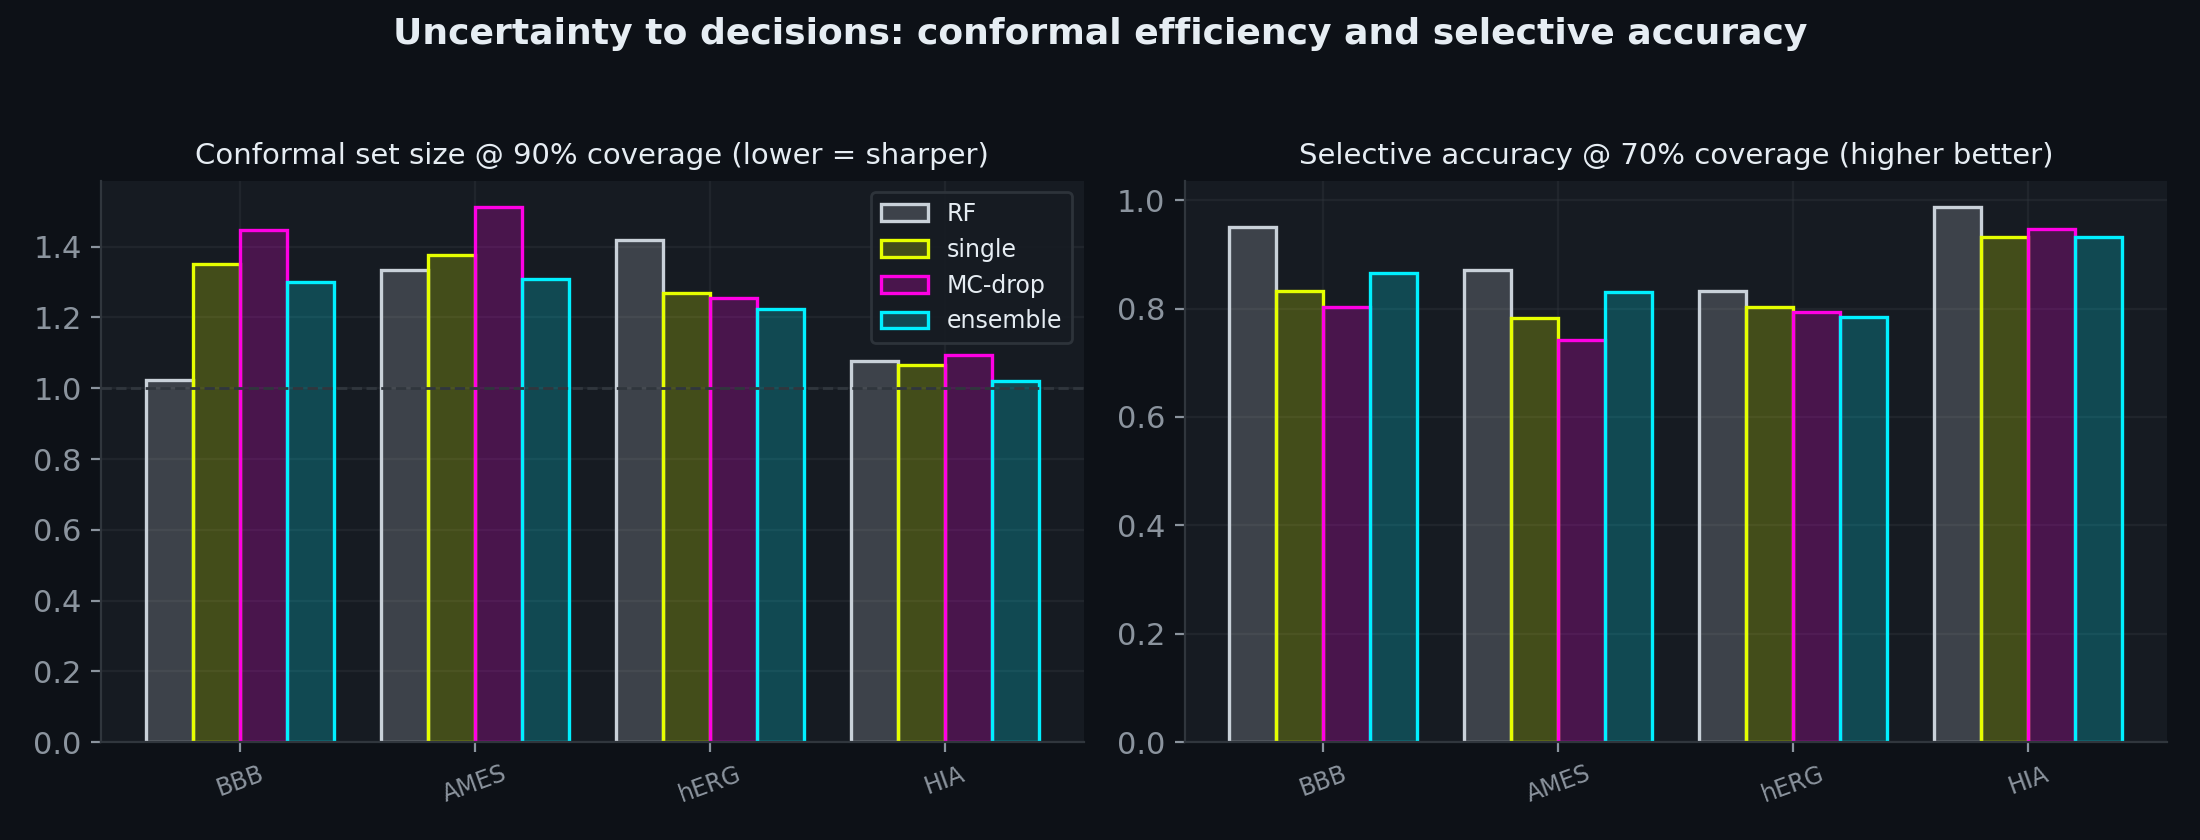

In [9]:
"""Conformal efficiency and selective accuracy: ensemble vs baselines.

Left panel: mean conformal set size at a fixed 90% coverage (sharper = lower). Right panel:
selective accuracy at 70% coverage (higher = better). Both are read off the committed
ensemble-uncertainty artifact and drawn per endpoint.
"""
show_fig("fig_conformal_efficiency.png", width=1000)

**Reading the efficiency panels.** At matched 90% coverage the ensemble produces the
sharpest sets of any graph model and, on AMES, hERG and HIA, undercuts even the descriptor
baseline; BBB is the exception where RF stays sharper. The selective-accuracy panel tells
the same story from the abstention side: declining the least-confident cases raises retained
accuracy fastest for the ensemble. Validity is guaranteed by construction; what the ensemble
buys is efficiency.

## 4.6 Interpretability: do attention maps recover descriptor rules?

A common hope is that a graph-attention network's weights will highlight the substructures a
chemist would. We test that directly and report a negative result. We train a GAT [4], read
its final-layer node attention, and ask whether the atoms it attends to line up with a
transparent descriptor rule (aromatic or nitrogen atoms, the lipophilic-ring and basic-amine
motifs that dominate e.g. hERG and CNS chemistry). Agreement is scored by the AUROC of
node-attention against the rule, and by the salient-atom enrichment among the top-3 attended
atoms.

endpoint    GAT AUROC  att->salience AUROC  top3 enrich
-------------------------------------------------------
herg            0.770                0.521        0.038
bbb             0.756                0.488       -0.037

node-level AUROC ~ 0.5 = attention ranks atoms at chance against the rule.


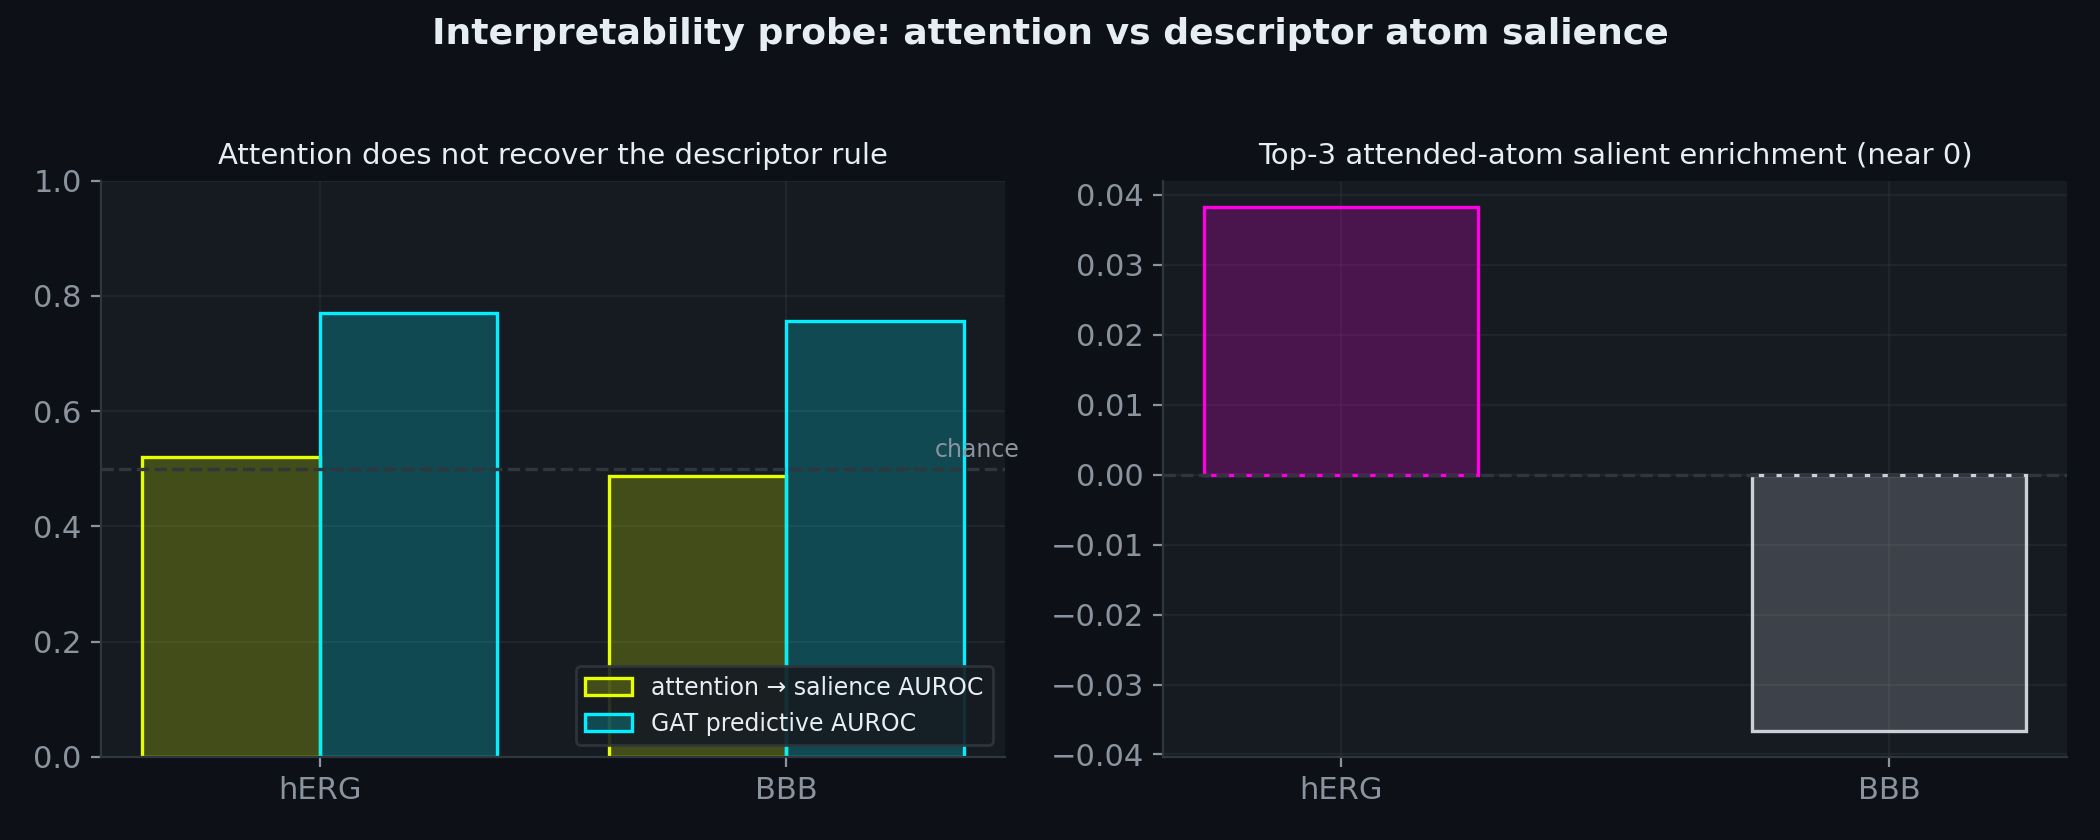

In [10]:
"""Attention-vs-salience probe (from attention_attribution.json).

Prints, per endpoint, the GAT's predictive AUROC, the AUROC of node attention against the
descriptor salience rule, and the top-3 salient-atom enrichment. A node-level AUROC near 0.5
means attention ranks atoms at chance against the rule, i.e. it does not recover it.
"""
att = json.loads((ART / "attention_attribution.json").read_text())["results"]
hdr = f"{'endpoint':10s} {'GAT AUROC':>10s} {'att->salience AUROC':>20s} {'top3 enrich':>12s}"
print(hdr); print("-" * len(hdr))
for k, r in att.items():
    print(f"{k:10s} {r['test_auroc']:10.3f} {r['node_attention_auroc']:20.3f} "
          f"{r['topk_enrichment']:12.3f}")
print("\nnode-level AUROC ~ 0.5 = attention ranks atoms at chance against the rule.")
show_fig("fig_attention_probe.png", width=1000)

**Reading the probe.** The GAT is genuinely predictive (test AUROC in the high 0.7s), yet
its attention aligns with the descriptor rule only at chance (node AUROC near 0.5) and the
top-3 enrichment sits near zero. Attention here is not a faithful explanation, exactly the
caution raised by Jain and Wallace [19]. We keep this negative result in the main line
rather than quietly drop it.

## 4.7 End-to-end autonomous campaign with the learned oracle

Finally we compose the pieces into one closed loop: the learned multi-task ensemble oracle
scores candidates, the SPRT of §4.4 decides when to stop, and every decision, oracle
prediction, and trace is logged to a DuckDB lineage store. This section reports the
aggregate outcome of that campaign across the classification endpoints.

In [11]:
"""Aggregate campaign outcome (from campaign_learned.json).

Prints the number of GO decisions, the total measurements the sequential campaign spent
against the fixed-sample budget, and the aggregate percentage saved. The per-endpoint SPRT
detail behind these totals is in §4.4.
"""
camp = json.loads((ART / "campaign_learned.json").read_text())
s = camp["summary"]
print(f"oracle: {camp['oracle']}")
print(f"{s['n_go_decisions']}/{s['n_endpoints']} GO  |  "
      f"{s['total_measurements_used']} vs {s['total_fixed_sample']} measurements  |  "
      f"{s['pct_saved']}% saved")

# Provenance: every decision is logged to a DuckDB lineage store. Show the path and the
# per-endpoint experiment IDs so the go/no-go calls are traceable end to end.
print(f"\nDuckDB lineage: {camp['lineage_duckdb']}")
for k, r in camp["per_endpoint"].items():
    print(f"  {k:6s} experiment_id={r['experiment_id'][:8]}  verdict={r['sprt']['verdict']}")

oracle: K=5 deep ensemble (multi-task graph stack)
3/4 GO  |  150 vs 213.4 measurements  |  29.7% saved

DuckDB lineage: pilot_phd/preprint/dl_forward/artifacts/campaign_learned_lineage.duckdb
  bbb    experiment_id=580240b4  verdict=GO (meaningful shift)
  ames   experiment_id=79fad8d2  verdict=GO (meaningful shift)
  herg   experiment_id=fb9122eb  verdict=GO (meaningful shift)
  hia    experiment_id=fc6d1fbb  verdict=UNDECIDED (budget)


**Reading the campaign.** The learned oracle returns confident GO calls on the majority of
endpoints while spending materially fewer measurements than a fixed-sample design, and the
undecided and higher-cost cases are reported in the same totals rather than filtered out.
Because every step is written to the lineage store, the campaign is auditable end to end,
which is the property that makes an autonomous loop trustworthy.

## 4.8 The definitive results table

One table ties the study together: per endpoint, the RF / single / multi point metrics at
full data with the ensemble-vs-RF decision columns. It is the capstone, read after the
per-section evidence above. (The pretraining-ablation numbers are their own table in §4.2,
since they live on a different axis, low-data training-strategy deltas rather than full-data
model-family point metrics.)

In [12]:
"""Assemble the definitive table from the committed JSON.

For each endpoint we take the full-data point metric for RF / single / multi, the
multi-minus-single delta, and the ensemble-vs-RF calibration and conformal columns
(classification endpoints only). Rendered as a DataFrame so it displays as a clean table.
"""
import pandas as pd

p1 = json.loads((ART / "multitask_metrics.json").read_text())
ens = json.loads((ART / "ensemble_uncertainty.json").read_text())["results"]
frac = p1["config"]["train_fractions"][-1]  # full-data operating point
rows = []
for k, s in p1["summary"].items():
    m = "auroc" if s["task"] == "clf" else "mae"
    def at(method):
        return next(x["mean"] for x in s[method][m]["by_fraction"] if x["fraction"] == frac)
    row = {"endpoint": k, "task": s["task"], "metric": m,
           "RF": round(at("rf"), 3), "GNN-single": round(at("gnn_single"), 3),
           "GNN-multi": round(at("gnn_multi"), 3),
           "Δ(multi-single)": round(at("gnn_multi") - at("gnn_single"), 3)}
    if k in ens:  # decision columns exist for classification endpoints only
        row["ECE_rf"] = round(ens[k]["rf"]["ece"], 3)
        row["ECE_ens"] = round(ens[k]["ensemble"]["ece"], 3)
        row["set@90_rf"] = round(ens[k]["rf"]["conf_set_size_at_90"], 3)
        row["set@90_ens"] = round(ens[k]["ensemble"]["conf_set_size_at_90"], 3)
    rows.append(row)
pd.DataFrame(rows)

,endpoint,task,metric,RF,GNN-single,GNN-multi,Δ(multi-single),ECE_rf,ECE_ens,set@90_rf,set@90_ens
0,bbb,clf,auroc,0.892,0.815,0.815,-0.000,0.051,0.085,1.024,1.299
1,ames,clf,auroc,0.817,0.761,0.712,-0.049,0.052,0.055,1.333,1.309
2,herg,clf,auroc,0.865,0.759,0.774,0.016,0.057,0.060,1.418,1.222
3,hia,clf,auroc,0.945,0.929,0.920,-0.009,0.052,0.074,1.075,1.019
4,solubility,reg,mae,0.842,1.215,1.360,0.145,NaN,NaN,NaN,NaN
5,caco2,reg,mae,0.399,0.658,0.486,-0.172,NaN,NaN,NaN,NaN


**Reading the capstone.** Scan the `Δ(multi-single)` column for the transfer story and the
`set@90` pair for the decision story. RF leads the raw-accuracy columns on every endpoint,
the defensible bound on the graph-model claims; the multi-task encoder earns its place through
low-data transfer (§4.1) and the ensemble through sharper decision-grade uncertainty
(§4.3-§4.5).

## 5. Reproducibility

**Tier 1 (this notebook, CPU, seconds).** Everything above renders committed artifacts, so a
reviewer reads the full study in seconds.

**Tier 2 (GPU).** Regenerate from scratch with the same scripts the manuscript cites. The
cell below is gated on `RECOMPUTE` (set in the setup cell) so a normal read never triggers
hours of training. For a quick pipeline check it runs the CPU smoke path; on a GPU host, run
the full commands in the comment to reproduce the paper numbers.

In [13]:
"""Optional recompute (Tier 2): same CLI the manuscript cites, identical code path."""
if RECOMPUTE:
    import subprocess
    # Fast plumbing check (CPU). For the full paper numbers on a GPU host, run instead:
    #   make train-gnn
    #   python pilot_phd/preprint/dl_forward/make_ensemble_uncertainty.py
    #   python pilot_phd/preprint/dl_forward/pretrain_ablation.py --full
    #   python pilot_phd/preprint/dl_forward/figures.py
    subprocess.run([sys.executable, str(DL / "train_multitask_gnn.py"), "--smoke"],
                   cwd=str(DL), check=True)
    print("smoke recompute done; see artifacts/")
else:
    print("RECOMPUTE is False - rendering committed artifacts only (fast path).")

RECOMPUTE is False - rendering committed artifacts only (fast path).


## Generative AI Disclosure

Some assertions and model development steps within this notebook were developed with
reference to Generative AI tools (Copilot; 2026 version). AI assistance was used for
clarifying concepts, validating code logic, identifying potential errors, and generating
some code segments. All AI-generated material was independently reviewed, debugged, and
validated for correctness before inclusion.

## References

1. Wald, A. (1945). Sequential tests of statistical hypotheses. *Annals of Mathematical Statistics*, 16(2), 117-186.
2. Wald, A. and Wolfowitz, J. (1948). Optimum character of the sequential probability ratio test. *Annals of Mathematical Statistics*, 19(3), 326-339.
3. Kipf, T. N. and Welling, M. (2017). Semi-supervised classification with graph convolutional networks. *ICLR*.
4. Velickovic, P., Cucurull, G., Casanova, A., Romero, A., Lio, P. and Bengio, Y. (2018). Graph attention networks. *ICLR*.
5. Xu, K., Hu, W., Leskovec, J. and Jegelka, S. (2019). How powerful are graph neural networks? *ICLR*.
6. Gilmer, J., Schoenholz, S. S., Riley, P. F., Vinyals, O. and Dahl, G. E. (2017). Neural message passing for quantum chemistry. *ICML*.
7. Hu, W., Liu, B., Gomes, J., Zitnik, M., Liang, P., Pande, V. and Leskovec, J. (2020). Strategies for pre-training graph neural networks. *ICLR*.
8. Zhao, L. and Akoglu, L. (2020). PairNorm: tackling oversmoothing in GNNs. *ICLR*.
9. Rong, Y., Huang, W., Xu, T. and Huang, J. (2020). DropEdge: towards deep graph convolutional networks on node classification. *ICLR*.
10. Lakshminarayanan, B., Pritzel, A. and Blundell, C. (2017). Simple and scalable predictive uncertainty estimation using deep ensembles. *NeurIPS*.
11. Guo, C., Pleiss, G., Sun, Y. and Weinberger, K. Q. (2017). On calibration of modern neural networks. *ICML*.
12. Gal, Y. and Ghahramani, Z. (2016). Dropout as a Bayesian approximation: representing model uncertainty in deep learning. *ICML*.
13. Vovk, V., Gammerman, A. and Shafer, G. (2005). *Algorithmic Learning in a Random World*. Springer.
14. Angelopoulos, A. N. and Bates, S. (2023). Conformal prediction: a gentle introduction. *Foundations and Trends in Machine Learning*, 16(4), 494-591.
15. El-Yaniv, R. and Wiener, Y. (2010). On the foundations of noise-free selective classification. *JMLR*, 11, 1605-1641.
16. Geifman, Y. and El-Yaniv, R. (2017). Selective classification for deep neural networks. *NeurIPS*.
17. Huang, K., Fu, T., Gao, W., et al. (2021). Therapeutics Data Commons: machine learning datasets and tasks for drug discovery and development. *NeurIPS Datasets and Benchmarks*.
18. Bemis, G. W. and Murcko, M. A. (1996). The properties of known drugs. 1. Molecular frameworks. *Journal of Medicinal Chemistry*, 39(15), 2887-2893.
19. Jain, S. and Wallace, B. C. (2019). Attention is not explanation. *NAACL-HLT*.